In [1]:
import ast
import os
import pandas as pd

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_data = f'{base_folder}/figure_data'
os.makedirs(figure_data, exist_ok=True)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
import re

def extract_cogs(og_str):
    if pd.isna(og_str) or og_str == "-":
        return set()
    cog_list = re.findall(r"COG\d+", og_str)
    return set(cog_list)

def cog_count_calcu(cog_data):
    cog_data['cogs'] = cog_data.copy()['eggNOG_OGs'].apply(extract_cogs)
    cog_count = {}
    for cogs in cog_data[cog_data['COG_category_corrected'].str.contains('X', na=False)]['cogs']:
        for cog in cogs:
            try:
                cog_count[cog] += 1
            except:
                cog_count[cog] = 1
    
    df_cog = pd.DataFrame(
        sorted(cog_count.items(), key=lambda x: x[1], reverse=True),
        columns=["COG_ID", "count"]
    )
    return df_cog

COG_data_dir = '/active-data/datasets/COG_data'
COG_table = pd.read_csv(f'{COG_data_dir}/cog-24.def.tsv', sep='\t')
COG_info = pd.read_csv(f'{COG_data_dir}/cog-24.fun.tsv', sep='\t')

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = ['Arial']
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

def draw_fraction_bar(ax, chro_perc, random_perc):
    df = pd.DataFrame({"Samples near split sites": chro_perc, "Random samples": random_perc})
    labels = df.index.tolist()
    x = np.arange(len(labels))
    bar_width = 0.35
    
    bar1 = ax.bar(x - bar_width/2, df["Samples near split sites"], width=bar_width, label="Samples near fission-fusion sites", color="#1f77b4")
    bar2 = ax.bar(x + bar_width/2, df["Random samples"], width=bar_width, label="Random samples", color="#ff7f0e")
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Protein\npercentage (%)", labelpad=0)
    ax.set_xlim(-0.5, len(df)-0.5)
    for tick_label in ax.get_xticklabels():
        if tick_label.get_text() == "X":
            tick_label.set_color("#d62728")
            tick_label.set_weight("bold")

def plot_top_cog(ax, sorted_cog_count, top_n=5):
    df_top = sorted_cog_count.head(top_n).copy()
    df_top["label"] = df_top["COG_ID"] + " | " + df_top["Gene_Name"]
    
    y_pos = list(range(len(df_top)))
    bars = ax.barh(df_top.index, df_top["count"])
    ax.invert_yaxis()
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_top["label"], ha="left", fontsize=6.5)
    ax.yaxis.tick_right()
    
    # ax.set_xlabel("Count", labelpad=0)

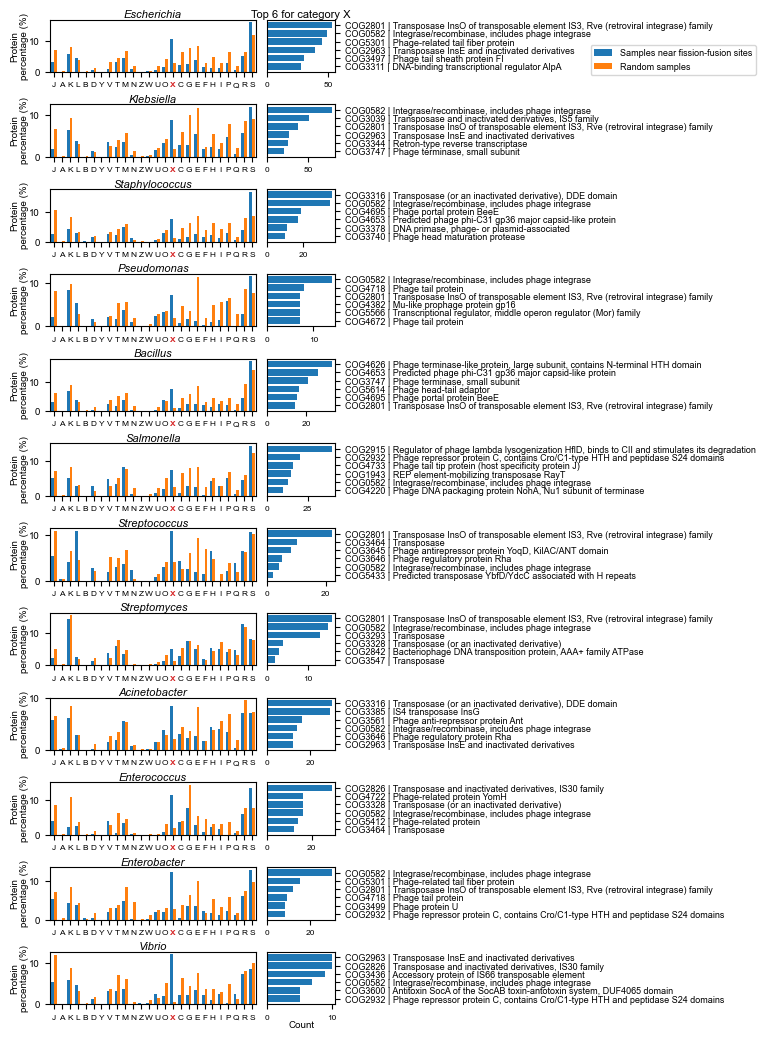

In [4]:
fig = plt.figure(figsize=(7.5, 7.5))

i = 0
gap = 0.003
for genus_name in keep_genus:
    target_folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    try:
        all_cog_data = pd.read_csv(f'{target_folder}/IRs_on_chromosome_gap_cog_result.tsv', sep='\t')
        all_cog_data = all_cog_data[all_cog_data["Psudogene"] == False]
        random_cog_data = pd.read_csv(f'{target_folder}/IRs_random_chromosome_gap_cog_result.tsv', sep='\t')
        random_cog_data = random_cog_data[random_cog_data["Psudogene"] == False]
    except:
        continue

    # print(genus_name, len(all_cog_data))
    if all_cog_data.empty or random_cog_data.empty or len(all_cog_data) < 400:
        continue
    
    chro_perc = {}
    random_perc = {}
    for char in COG_info['char']:
        chro_perc[char] = len(all_cog_data[all_cog_data['COG_category_corrected'].str.contains(char, na=False)])/len(all_cog_data)*100
        random_perc[char] = len(random_cog_data[random_cog_data['COG_category_corrected'].str.contains(char, na=False)])/len(random_cog_data)*100
    
    sorted_cog_count = cog_count_calcu(all_cog_data)
    sorted_cog_count = pd.merge(sorted_cog_count, COG_table[['COG_ID', 'Gene_Name']], on='COG_ID', how='left')

    i += 1
    rep_y_site = 1 - 0.11*i - gap*(i - 1) + 0.025
    ax_frac = fig.add_axes([0.055, rep_y_site, 0.275, 0.07])
    draw_fraction_bar(ax_frac, chro_perc, random_perc)
    ax_frac.set_title(genus_name, fontstyle='italic', pad=1)
    
    ax_gene = fig.add_axes([0.055 + 0.42-0.13, rep_y_site, 0.09, 0.07])
    plot_top_cog(ax_gene, sorted_cog_count, top_n=6)
    if i == 1:
        ax_gene.set_title('Top 6 for category X', pad=1)
        ax_frac.legend(loc="upper left", bbox_to_anchor=(2.6, 0.6))

ax_gene.set_xlabel("Count", labelpad=0)
rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_genera_split_site_cog_result.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_genera_split_site_cog_result.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()